# US Non-Housing Services PCE Diffusion Index

This notebook recreates a Fed-style weighted diffusion index for US non-housing services PCE using the 67-line `supercore_lines.xlsx` universe. It pulls monthly BEA `NIUnderlyingDetail` data for price indexes (`U20404`) and current-dollar PCE expenditures (`U20405`), calculates user-selected component inflation, applies same-month expenditure weights, buckets each component by editable thresholds, and exports tidy CSVs plus stacked charts.

The workbook must include `Line`, `Item`, and `Category`. The category field is used to build a Figure 5-style period-average stacked bar chart for non-housing services inflation.


In [31]:
from datetime import date
from pathlib import Path
import json
import math
import os
import time
import urllib.parse
import urllib.request

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont


In [32]:
# Public notebook parameters. Edit these values directly, or override them with matching environment variables.
LINE_FILE = os.environ.get("LINE_FILE", "supercore_lines.xlsx")
API_KEYS_FILE = os.environ.get("API_KEYS_FILE", "API Keys.txt")
START_YEAR = int(os.environ.get("START_YEAR", "2014"))
END_YEAR = int(os.environ.get("END_YEAR", str(date.today().year)))
CHANGE_MONTHS = int(os.environ.get("CHANGE_MONTHS", "12"))
CATEGORY_DIFFUSION_BUCKET = os.environ.get("CATEGORY_DIFFUSION_BUCKET", "Above upper")
LOWER_THRESHOLD = float(os.environ.get("LOWER_THRESHOLD", "0.0"))
UPPER_THRESHOLD = float(os.environ.get("UPPER_THRESHOLD", "4.0"))
OUTPUT_DIR = os.environ.get("OUTPUT_DIR", "outputs")

PRICE_TABLE = "U20404"       # Table 2.4.4U price indexes for PCE by type of product
EXPENDITURE_TABLE = "U20405" # Table 2.4.5U current-dollar PCE expenditures
BEA_DATASET = "NIUnderlyingDetail"
BEA_API_URL = "https://apps.bea.gov/api/data/"

ALLOWED_CHANGE_MONTHS = {3, 6, 12}
BUCKET_ORDER = ["Above upper", "Between", "Below lower"]
CHART_ORDER = ["Below lower", "Between", "Above upper"]
PERIOD_ORDER = ["2014-2019", "2020-2025", "2026 YTD"]
HORIZON_LABELS = {
    12: "12-month",
    6: "6-month annualized",
    3: "3-month annualized",
}

BUCKET_COLORS = {
    "Above upper": "#B33B32",
    "Between": "#D8CAB2",
    "Below lower": "#426F9F",
}
CATEGORY_COLORS = {
    "Utilities": "#4E79A7",
    "Health": "#59A14F",
    "Transportation": "#F28E2B",
    "Recreation": "#9C755F",
    "Financials": "#B07AA1",
    "Food & Acc": "#EDC948",
    "Other": "#BAB0AC",
}

if CHANGE_MONTHS not in ALLOWED_CHANGE_MONTHS:
    raise ValueError(f"CHANGE_MONTHS must be one of {sorted(ALLOWED_CHANGE_MONTHS)}, not {CHANGE_MONTHS}.")
if CATEGORY_DIFFUSION_BUCKET not in BUCKET_ORDER:
    raise ValueError(f"CATEGORY_DIFFUSION_BUCKET must be one of {BUCKET_ORDER}, not {CATEGORY_DIFFUSION_BUCKET!r}.")
if LOWER_THRESHOLD > UPPER_THRESHOLD:
    raise ValueError("LOWER_THRESHOLD must be less than or equal to UPPER_THRESHOLD.")

HORIZON_LABEL = HORIZON_LABELS[CHANGE_MONTHS]
ANNUALIZATION_POWER = 12 / CHANGE_MONTHS

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Using {HORIZON_LABEL} inflation changes.")
print(f"Category chart decomposes: {CATEGORY_DIFFUSION_BUCKET}.")


Using 12-month inflation changes.
Category chart decomposes: Above upper.


In [33]:
def load_bea_key(path):
    key_path = Path(path)
    if not key_path.exists():
        raise FileNotFoundError(f"Could not find BEA key file: {key_path}")

    for raw_line in key_path.read_text(encoding="utf-8-sig").splitlines():
        line = raw_line.strip()
        if not line or ":" not in line:
            continue
        label, value = line.split(":", 1)
        if label.strip().lower() == "bea" and value.strip():
            return value.strip()

    raise ValueError(f"Could not find a non-empty 'BEA:' entry in {key_path}")


bea_key = load_bea_key(API_KEYS_FILE)
print("Loaded BEA API key from local key file.")


Loaded BEA API key from local key file.


In [34]:
line_items = pd.read_excel(LINE_FILE)
required_columns = {"Line", "Item", "Category"}
missing_columns = required_columns.difference(line_items.columns)
if missing_columns:
    raise ValueError(f"{LINE_FILE} is missing required columns: {sorted(missing_columns)}")

line_items = (
    line_items.loc[:, ["Line", "Item", "Category"]]
    .rename(columns={"Line": "line_number", "Item": "item", "Category": "category"})
    .copy()
)
line_items["line_number"] = pd.to_numeric(line_items["line_number"], errors="raise").astype(int)
line_items["item"] = line_items["item"].astype(str).str.strip()
line_items["category"] = line_items["category"].astype("string").str.strip()

missing_category = line_items["category"].isna() | (line_items["category"] == "")
if missing_category.any():
    details = line_items.loc[missing_category, ["line_number", "item"]].to_string(index=False)
    raise ValueError(f"{LINE_FILE} has missing categories for these rows:\n{details}")

if line_items["line_number"].duplicated().any():
    dupes = line_items.loc[line_items["line_number"].duplicated(), "line_number"].tolist()
    raise ValueError(f"Duplicate workbook line numbers found: {dupes}")

line_items["category"] = line_items["category"].astype(str)
line_numbers = line_items["line_number"].tolist()
category_order = line_items["category"].drop_duplicates().tolist()
category_colors = {
    category: CATEGORY_COLORS.get(category, f"#{(idx * 2654435761) & 0xFFFFFF:06X}")
    for idx, category in enumerate(category_order)
}

print(f"Loaded {len(line_items)} line items from {LINE_FILE}.")
print(f"Loaded {len(category_order)} categories: {', '.join(category_order)}")
line_items.head()


Loaded 67 line items from supercore_lines.xlsx.
Loaded 7 categories: Utilities, Health, Transportation, Recreation, Food & Acc, Financials, Other


,line_number,item,category
0,166,Water supply and sanitation (25),Utilities
1,174,Physician services (44),Health
2,175,Dental services (45),Health
3,176,Paramedical services (46),Health
4,183,Hospitals (51),Health


In [35]:
def fetch_bea_table(table_name, start_year, end_year, api_key, retries=3, pause_seconds=1.0):
    years = ",".join(str(year) for year in range(start_year, end_year + 1))
    params = {
        "UserID": api_key,
        "method": "GetData",
        "DataSetName": BEA_DATASET,
        "TableName": table_name,
        "Frequency": "M",
        "Year": years,
        "ResultFormat": "JSON",
    }
    url = BEA_API_URL + "?" + urllib.parse.urlencode(params)

    last_error = None
    for attempt in range(1, retries + 1):
        try:
            with urllib.request.urlopen(url, timeout=90) as response:
                payload = json.loads(response.read().decode("utf-8"))
            break
        except Exception as exc:
            last_error = exc
            if attempt == retries:
                raise RuntimeError(f"BEA request failed for {table_name}: {exc}") from exc
            time.sleep(pause_seconds * attempt)
    else:
        raise RuntimeError(f"BEA request failed for {table_name}: {last_error}")

    api_root = payload.get("BEAAPI", {})
    if "Error" in api_root:
        raise RuntimeError(f"BEA API error for {table_name}: {api_root['Error']}")

    results = api_root.get("Results", {})
    if isinstance(results, dict) and "Error" in results:
        raise RuntimeError(f"BEA API error for {table_name}: {results['Error']}")

    data = results.get("Data", [])
    if not data:
        raise ValueError(f"BEA returned no rows for {table_name}.")

    return pd.DataFrame(data)


def parse_bea_month(time_period):
    period_text = str(time_period)
    if "M" not in period_text:
        return pd.NaT
    year_text, month_text = period_text.split("M", 1)
    return pd.Period(year=int(year_text), month=int(month_text), freq="M")


def clean_bea_table(raw_df, value_name):
    cleaned = raw_df.copy()
    cleaned["line_number"] = pd.to_numeric(cleaned["LineNumber"], errors="raise").astype(int)
    cleaned["month"] = cleaned["TimePeriod"].map(parse_bea_month)
    cleaned[value_name] = (
        cleaned["DataValue"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace({"": np.nan, "(NA)": np.nan, "NA": np.nan, "--": np.nan, "---": np.nan})
        .pipe(pd.to_numeric, errors="coerce")
    )

    cleaned = cleaned.loc[
        cleaned["line_number"].isin(line_numbers),
        ["line_number", "month", value_name, "LineDescription", "SeriesCode"],
    ].copy()

    if cleaned["month"].isna().any():
        bad = cleaned.loc[cleaned["month"].isna(), "line_number"].drop_duplicates().tolist()
        raise ValueError(f"Could not parse monthly dates for lines: {bad}")

    return cleaned


def validate_line_coverage(cleaned_df, table_name):
    present = set(cleaned_df["line_number"].dropna().astype(int).unique())
    missing = [line for line in line_numbers if line not in present]
    if missing:
        missing_items = line_items[line_items["line_number"].isin(missing)].copy()
        details = missing_items.to_string(index=False)
        raise ValueError(f"{table_name} is missing {len(missing)} workbook line(s):\n{details}")
    print(f"{table_name}: all {len(line_numbers)} workbook lines found.")


In [36]:
fetch_start_year = START_YEAR - 1
print(f"Pulling BEA monthly data for {fetch_start_year}-{END_YEAR}...")

raw_prices = fetch_bea_table(PRICE_TABLE, fetch_start_year, END_YEAR, bea_key)
raw_expenditures = fetch_bea_table(EXPENDITURE_TABLE, fetch_start_year, END_YEAR, bea_key)

prices = clean_bea_table(raw_prices, "price_index")
expenditures = clean_bea_table(raw_expenditures, "expenditure")

validate_line_coverage(prices, PRICE_TABLE)
validate_line_coverage(expenditures, EXPENDITURE_TABLE)
print(f"Price rows selected: {len(prices):,}")
print(f"Expenditure rows selected: {len(expenditures):,}")


Pulling BEA monthly data for 2013-2026...
U20404: all 67 workbook lines found.
U20405: all 67 workbook lines found.
Price rows selected: 10,653
Expenditure rows selected: 10,653


In [37]:
price_levels = prices.loc[:, ["line_number", "month", "price_index"]].copy()
price_lags = price_levels.rename(columns={"price_index": "price_index_lag"}).copy()
price_lags["month"] = price_lags["month"] + CHANGE_MONTHS

component = (
    price_levels
    .merge(price_lags, on=["line_number", "month"], how="inner", validate="one_to_one")
    .merge(expenditures.loc[:, ["line_number", "month", "expenditure"]], on=["line_number", "month"], how="left", validate="one_to_one")
    .merge(line_items, on="line_number", how="left", validate="many_to_one")
)

component = component[component["month"].dt.year >= START_YEAR].copy()
if (component[["price_index", "price_index_lag"]] <= 0).any().any():
    bad = component.loc[(component["price_index"] <= 0) | (component["price_index_lag"] <= 0), ["month", "line_number", "item"]]
    raise ValueError(f"Price index values must be positive for percentage changes. First affected rows:\n{bad.head(20).to_string(index=False)}")

component["inflation_rate"] = 100.0 * ((component["price_index"] / component["price_index_lag"]) ** ANNUALIZATION_POWER - 1.0)

missing_values = component[
    component[["price_index", "price_index_lag", "expenditure", "inflation_rate"]].isna().any(axis=1)
]
if not missing_values.empty:
    sample = missing_values.loc[:, ["month", "line_number", "item"]].head(20).to_string(index=False)
    raise ValueError(f"Missing values after merging BEA data. First affected rows:\n{sample}")

monthly_counts = component.groupby("month")["line_number"].nunique()
bad_counts = monthly_counts[monthly_counts != len(line_numbers)]
if not bad_counts.empty:
    raise ValueError(
        "Some months do not have the full workbook universe after merging:\n"
        + bad_counts.head(20).to_string()
    )

component["total_expenditure"] = component.groupby("month")["expenditure"].transform("sum")
zero_weight_months = component.loc[component["total_expenditure"].abs() < 1e-12, "month"].drop_duplicates()
if not zero_weight_months.empty:
    raise ValueError(f"Total selected expenditure is zero in: {zero_weight_months.astype(str).tolist()}")

component["weight"] = component["expenditure"] / component["total_expenditure"]
component["weight_pct"] = 100.0 * component["weight"]

component["bucket"] = np.select(
    [
        component["inflation_rate"] > UPPER_THRESHOLD,
        component["inflation_rate"] < LOWER_THRESHOLD,
    ],
    ["Above upper", "Below lower"],
    default="Between",
)

component["change_months"] = CHANGE_MONTHS
component["annualized"] = CHANGE_MONTHS in {3, 6}

weight_check = component.groupby("month")["weight_pct"].sum()
if not np.allclose(weight_check.to_numpy(), 100.0, atol=1e-8):
    worst = (weight_check - 100.0).abs().sort_values(ascending=False).head()
    raise AssertionError(f"Monthly weights do not sum to 100 within tolerance:\n{worst}")

component.head()


,line_number,month,price_index,price_index_lag,expenditure,item,category,inflation_rate,total_expenditure,weight,weight_pct,bucket,change_months,annualized
0,166,2014-01,88.050,85.193,88950,Water supply and sanitation (25),Utilities,3.353562,7208538,0.012340,1.233953,Between,12,False
1,166,2014-02,88.303,85.415,89222,Water supply and sanitation (25),Utilities,3.381139,7212835,0.012370,1.236989,Between,12,False
2,166,2014-03,88.573,85.676,89608,Water supply and sanitation (25),Utilities,3.381344,7254816,0.012352,1.235152,Between,12,False
3,166,2014-04,88.829,85.902,90080,Water supply and sanitation (25),Utilities,3.407371,7300770,0.012338,1.233842,Between,12,False
4,166,2014-05,88.964,86.200,90282,Water supply and sanitation (25),Utilities,3.206497,7357421,0.012271,1.227088,Between,12,False


In [38]:
diffusion = (
    component
    .pivot_table(index="month", columns="bucket", values="weight_pct", aggfunc="sum", fill_value=0.0)
    .reindex(columns=BUCKET_ORDER, fill_value=0.0)
    .sort_index()
)
diffusion["total_share"] = diffusion[BUCKET_ORDER].sum(axis=1)
diffusion["change_months"] = CHANGE_MONTHS
diffusion["horizon_label"] = HORIZON_LABEL
diffusion["lower_threshold"] = LOWER_THRESHOLD
diffusion["upper_threshold"] = UPPER_THRESHOLD

if not np.allclose(diffusion["total_share"].to_numpy(), 100.0, atol=1e-8):
    worst = (diffusion["total_share"] - 100.0).abs().sort_values(ascending=False).head()
    raise AssertionError(f"Monthly bucket shares do not sum to 100 within tolerance:\n{worst}")

latest_month = diffusion.index.max()
print(f"Latest available BEA month: {latest_month}")
diffusion.tail()


Latest available BEA month: 2026-03


bucket,Above upper,Between,Below lower,total_share,change_months,horizon_label,lower_threshold,upper_threshold
month,,,,,,,,
2025-11,42.103100,53.310249,4.586651,100.0,12,12-month,0.0,4.0
2025-12,20.546904,75.015801,4.437295,100.0,12,12-month,0.0,4.0
2026-01,23.529834,72.205318,4.264848,100.0,12,12-month,0.0,4.0
2026-02,21.154420,74.927458,3.918122,100.0,12,12-month,0.0,4.0
2026-03,26.642528,69.625583,3.731889,100.0,12,12-month,0.0,4.0


In [39]:
months = pd.PeriodIndex(sorted(component["month"].unique()), freq="M")
full_category_index = pd.MultiIndex.from_product(
    [months, category_order, BUCKET_ORDER],
    names=["month", "category", "bucket"],
)

category_monthly = (
    component
    .groupby(["month", "category", "bucket"], observed=False)["weight_pct"]
    .sum()
    .reindex(full_category_index, fill_value=0.0)
    .rename("share_pct")
    .reset_index()
)
category_monthly["change_months"] = CHANGE_MONTHS
category_monthly["horizon_label"] = HORIZON_LABEL
category_monthly["lower_threshold"] = LOWER_THRESHOLD
category_monthly["upper_threshold"] = UPPER_THRESHOLD


def period_label(month):
    year = month.year
    if 2014 <= year <= 2019:
        return "2014-2019"
    if 2020 <= year <= 2025:
        return "2020-2025"
    if year == 2026:
        return "2026 YTD"
    return pd.NA


category_selected = category_monthly[category_monthly["bucket"] == CATEGORY_DIFFUSION_BUCKET].copy()
category_selected["period"] = category_selected["month"].map(period_label)
category_selected = category_selected.dropna(subset=["period"]).copy()

period_month_counts = category_selected.groupby("period")["month"].nunique()
missing_periods = [period for period in PERIOD_ORDER if period_month_counts.get(period, 0) == 0]
if missing_periods:
    raise ValueError(f"No monthly data available for period(s): {missing_periods}")

period_category_average = (
    category_selected
    .groupby(["period", "category"], observed=False)["share_pct"]
    .mean()
    .reindex(pd.MultiIndex.from_product([PERIOD_ORDER, category_order], names=["period", "category"]), fill_value=0.0)
    .rename("average_share_pct")
    .reset_index()
)
period_category_average["selected_bucket"] = CATEGORY_DIFFUSION_BUCKET
period_category_average["change_months"] = CHANGE_MONTHS
period_category_average["horizon_label"] = HORIZON_LABEL
period_category_average["lower_threshold"] = LOWER_THRESHOLD
period_category_average["upper_threshold"] = UPPER_THRESHOLD

diffusion_period = diffusion.reset_index().rename(columns={"index": "month"})
diffusion_period["period"] = diffusion_period["month"].map(period_label)
diffusion_period = diffusion_period.dropna(subset=["period"]).copy()
selected_bucket_period_average = diffusion_period.groupby("period")[CATEGORY_DIFFUSION_BUCKET].mean().reindex(PERIOD_ORDER)
category_total_check = period_category_average.groupby("period")["average_share_pct"].sum().reindex(PERIOD_ORDER)
if not np.allclose(selected_bucket_period_average.to_numpy(), category_total_check.to_numpy(), atol=1e-8):
    check = pd.DataFrame({
        "selected_bucket_period_average": selected_bucket_period_average,
        "category_sum": category_total_check,
        "difference": category_total_check - selected_bucket_period_average,
    })
    raise AssertionError(f"Category bars do not sum to selected bucket period averages:\n{check}")

print("Category period sums match selected diffusion bucket averages.")
period_category_average.head()


Category period sums match selected diffusion bucket averages.


,period,category,average_share_pct,selected_bucket,change_months,horizon_label,lower_threshold,upper_threshold
0,2014-2019,Utilities,0.245497,Above upper,12,12-month,0.0,4.0
1,2014-2019,Health,0.199162,Above upper,12,12-month,0.0,4.0
2,2014-2019,Transportation,0.339316,Above upper,12,12-month,0.0,4.0
3,2014-2019,Recreation,0.542278,Above upper,12,12-month,0.0,4.0
4,2014-2019,Food & Acc,0.369776,Above upper,12,12-month,0.0,4.0


In [40]:
component_export = component.loc[
    :,
    [
        "month",
        "line_number",
        "item",
        "category",
        "change_months",
        "annualized",
        "price_index",
        "price_index_lag",
        "inflation_rate",
        "expenditure",
        "total_expenditure",
        "weight",
        "weight_pct",
        "bucket",
    ],
].copy()
component_export["month"] = component_export["month"].astype(str)

diffusion_export = diffusion.reset_index().rename(columns={"index": "month"}).copy()
diffusion_export["month"] = diffusion_export["month"].astype(str)

category_monthly_export = category_monthly.copy()
category_monthly_export["month"] = category_monthly_export["month"].astype(str)

period_category_export = period_category_average.copy()

component_csv = output_dir / "non_housing_services_pce_component_inflation_weights.csv"
diffusion_csv = output_dir / "non_housing_services_pce_monthly_diffusion_index.csv"
category_monthly_csv = output_dir / "non_housing_services_pce_monthly_category_bucket_contributions.csv"
period_category_csv = output_dir / "non_housing_services_pce_period_category_contributions.csv"

component_export.to_csv(component_csv, index=False)
diffusion_export.to_csv(diffusion_csv, index=False)
category_monthly_export.to_csv(category_monthly_csv, index=False)
period_category_export.to_csv(period_category_csv, index=False)

print(f"Saved component output to {component_csv}")
print(f"Saved monthly diffusion output to {diffusion_csv}")
print(f"Saved monthly category contribution output to {category_monthly_csv}")
print(f"Saved period category contribution output to {period_category_csv}")


Saved component output to outputs\non_housing_services_pce_component_inflation_weights.csv
Saved monthly diffusion output to outputs\non_housing_services_pce_monthly_diffusion_index.csv
Saved monthly category contribution output to outputs\non_housing_services_pce_monthly_category_bucket_contributions.csv
Saved period category contribution output to outputs\non_housing_services_pce_period_category_contributions.csv


In [41]:
def _font(size, bold=False):
    names = ["arialbd.ttf" if bold else "arial.ttf", "segoeui.ttf", "DejaVuSans.ttf"]
    for name in names:
        try:
            return ImageFont.truetype(name, size)
        except Exception:
            continue
    return ImageFont.load_default()


def _nice_ticks(y_min, y_max):
    if y_min >= -1e-8 and y_max <= 100.0 + 1e-8:
        return [0, 20, 40, 60, 80, 100]
    span = max(y_max - y_min, 1.0)
    raw_step = span / 5.0
    magnitude = 10 ** math.floor(math.log10(raw_step))
    step = min([1, 2, 5, 10], key=lambda x: abs(raw_step - x * magnitude)) * magnitude
    start = math.floor(y_min / step) * step
    stop = math.ceil(y_max / step) * step
    ticks = []
    value = start
    while value <= stop + step * 0.5:
        ticks.append(round(value, 10))
        value += step
    return ticks


def draw_diffusion_chart_from_csv(diffusion_csv_path, path):
    diffusion_df = pd.read_csv(diffusion_csv_path)
    diffusion_df["month"] = pd.PeriodIndex(diffusion_df["month"], freq="M")
    diffusion_df = diffusion_df.set_index("month")
    chart_df = diffusion_df.loc[:, CHART_ORDER].copy()
    months = list(chart_df.index.astype(str))
    values = {bucket: chart_df[bucket].astype(float).to_numpy() for bucket in CHART_ORDER}
    cumulative = np.zeros(len(chart_df), dtype=float)
    cumulative_values = [cumulative.copy()]
    for bucket in CHART_ORDER:
        cumulative = cumulative + values[bucket]
        cumulative_values.append(cumulative.copy())

    y_min = min(0.0, min(arr.min() for arr in cumulative_values))
    y_max = max(100.0, max(arr.max() for arr in cumulative_values))
    ticks = _nice_ticks(y_min, y_max)
    y_min = min(y_min, min(ticks))
    y_max = max(y_max, max(ticks))

    scale = 2
    width, height = 1400, 800
    margin_left, margin_right = 88, 42
    margin_top, margin_bottom = 118, 94
    plot_w = width - margin_left - margin_right
    plot_h = height - margin_top - margin_bottom

    img = Image.new("RGB", (width * scale, height * scale), "white")
    draw = ImageDraw.Draw(img)

    def sx(x):
        return int(round(x * scale))

    def sy(y):
        return int(round(y * scale))

    def x_pos(i):
        if len(months) == 1:
            return margin_left + plot_w / 2
        return margin_left + plot_w * i / (len(months) - 1)

    def y_pos(value):
        return margin_top + (y_max - value) / (y_max - y_min) * plot_h

    title_font = _font(28 * scale, bold=True)
    subtitle_font = _font(16 * scale)
    axis_font = _font(13 * scale)
    legend_font = _font(15 * scale)

    title = "US Non-Housing Services PCE Diffusion Index"
    subtitle = f"{HORIZON_LABEL} inflation buckets, expenditure-weighted shares; thresholds: {LOWER_THRESHOLD:g}% and {UPPER_THRESHOLD:g}%"
    draw.text((sx(margin_left), sy(30)), title, fill="#1F2933", font=title_font)
    draw.text((sx(margin_left), sy(70)), subtitle, fill="#52606D", font=subtitle_font)

    for tick in ticks:
        y = y_pos(tick)
        line_color = "#D9DEE7" if abs(tick) > 1e-12 else "#8A94A6"
        draw.line([(sx(margin_left), sy(y)), (sx(width - margin_right), sy(y))], fill=line_color, width=sx(1))
        label = f"{tick:g}%"
        bbox = draw.textbbox((0, 0), label, font=axis_font)
        draw.text((sx(margin_left - 12) - (bbox[2] - bbox[0]), sy(y - 8)), label, fill="#52606D", font=axis_font)

    base = np.zeros(len(chart_df), dtype=float)
    for bucket in CHART_ORDER:
        top = base + values[bucket]
        upper = [(sx(x_pos(i)), sy(y_pos(top[i]))) for i in range(len(months))]
        lower = [(sx(x_pos(i)), sy(y_pos(base[i]))) for i in range(len(months) - 1, -1, -1)]
        draw.polygon(upper + lower, fill=BUCKET_COLORS[bucket])
        base = top

    draw.rectangle(
        [sx(margin_left), sy(margin_top), sx(width - margin_right), sy(height - margin_bottom)],
        outline="#7B8794",
        width=sx(1),
    )

    month_periods = list(chart_df.index)
    years = sorted(set(period.year for period in month_periods))
    tick_periods = [pd.Period(year=year, month=1, freq="M") for year in years if pd.Period(year=year, month=1, freq="M") in month_periods]
    last_period = month_periods[-1]
    if tick_periods and tick_periods[-1].year == last_period.year:
        tick_periods[-1] = last_period
    elif last_period not in tick_periods:
        tick_periods.append(last_period)

    month_lookup = {period: i for i, period in enumerate(month_periods)}
    for period in tick_periods:
        i = month_lookup[period]
        x = x_pos(i)
        draw.line([(sx(x), sy(height - margin_bottom)), (sx(x), sy(height - margin_bottom + 6))], fill="#7B8794", width=sx(1))
        label = str(period.year) if period.month == 1 else str(period)
        bbox = draw.textbbox((0, 0), label, font=axis_font)
        draw.text((sx(x) - (bbox[2] - bbox[0]) // 2, sy(height - margin_bottom + 14)), label, fill="#52606D", font=axis_font)

    legend_x = margin_left
    legend_y = height - 44
    legend_labels = [("Above upper", BUCKET_COLORS["Above upper"]), ("Between", BUCKET_COLORS["Between"]), ("Below lower", BUCKET_COLORS["Below lower"])]
    for label, color in legend_labels:
        draw.rectangle([sx(legend_x), sy(legend_y), sx(legend_x + 20), sy(legend_y + 12)], fill=color, outline="#6B7280")
        draw.text((sx(legend_x + 28), sy(legend_y - 4)), label, fill="#1F2933", font=legend_font)
        bbox = draw.textbbox((0, 0), label, font=legend_font)
        legend_x += 28 + (bbox[2] - bbox[0]) / scale + 34

    source = f"Source: BEA {PRICE_TABLE}/{EXPENDITURE_TABLE}; latest month {months[-1]}"
    source_bbox = draw.textbbox((0, 0), source, font=axis_font)
    draw.text((sx(width - margin_right) - (source_bbox[2] - source_bbox[0]), sy(height - 44)), source, fill="#52606D", font=axis_font)

    img = img.resize((width, height), Image.Resampling.LANCZOS)
    img.save(path)


def draw_category_chart_from_csv(period_category_csv_path, path):
    source_df = pd.read_csv(period_category_csv_path)
    pivot = (
        source_df
        .pivot(index="period", columns="category", values="average_share_pct")
        .reindex(index=PERIOD_ORDER, columns=category_order, fill_value=0.0)
        .fillna(0.0)
    )
    values = pivot.to_numpy(dtype=float)
    pos_totals = np.clip(values, 0, None).sum(axis=1)
    neg_totals = np.clip(values, None, 0).sum(axis=1)
    y_min = min(0.0, float(neg_totals.min()))
    y_max = max(5.0, float(pos_totals.max()))
    ticks = _nice_ticks(y_min, y_max)
    y_min = min(y_min, min(ticks))
    y_max = max(y_max, max(ticks))

    scale = 2
    width, height = 1100, 760
    margin_left, margin_right = 88, 40
    margin_top, margin_bottom = 124, 162
    plot_w = width - margin_left - margin_right
    plot_h = height - margin_top - margin_bottom

    img = Image.new("RGB", (width * scale, height * scale), "white")
    draw = ImageDraw.Draw(img)

    def sx(x):
        return int(round(x * scale))

    def sy(y):
        return int(round(y * scale))

    def y_pos(value):
        return margin_top + (y_max - value) / (y_max - y_min) * plot_h

    title_font = _font(26 * scale, bold=True)
    subtitle_font = _font(15 * scale)
    axis_font = _font(13 * scale)
    legend_font = _font(14 * scale)
    label_font = _font(14 * scale, bold=True)

    draw.text((sx(margin_left), sy(30)), "Category Contribution to Non-Housing Services Diffusion", fill="#1F2933", font=title_font)
    subtitle = f"Average contribution to '{CATEGORY_DIFFUSION_BUCKET}' share; {HORIZON_LABEL} inflation, percentage points"
    draw.text((sx(margin_left), sy(68)), subtitle, fill="#52606D", font=subtitle_font)

    for tick in ticks:
        y = y_pos(tick)
        line_color = "#D9DEE7" if abs(tick) > 1e-12 else "#8A94A6"
        draw.line([(sx(margin_left), sy(y)), (sx(width - margin_right), sy(y))], fill=line_color, width=sx(1))
        label = f"{tick:g}"
        bbox = draw.textbbox((0, 0), label, font=axis_font)
        draw.text((sx(margin_left - 12) - (bbox[2] - bbox[0]), sy(y - 8)), label, fill="#52606D", font=axis_font)

    bar_count = len(PERIOD_ORDER)
    slot_w = plot_w / bar_count
    bar_w = min(150, slot_w * 0.46)
    zero_y = y_pos(0)

    for period_idx, period in enumerate(PERIOD_ORDER):
        center_x = margin_left + slot_w * (period_idx + 0.5)
        x0 = center_x - bar_w / 2
        x1 = center_x + bar_w / 2
        pos_base = 0.0
        neg_base = 0.0
        for category in category_order:
            value = float(pivot.loc[period, category])
            if abs(value) < 1e-12:
                continue
            color = category_colors[category]
            if value >= 0:
                y0 = y_pos(pos_base + value)
                y1 = y_pos(pos_base)
                pos_base += value
            else:
                y0 = y_pos(neg_base)
                y1 = y_pos(neg_base + value)
                neg_base += value
            draw.rectangle([sx(x0), sy(y0), sx(x1), sy(y1)], fill=color, outline="#FFFFFF", width=sx(1))

        total = pivot.loc[period].sum()
        total_label = f"{total:.1f}"
        bbox = draw.textbbox((0, 0), total_label, font=label_font)
        label_y = y_pos(pos_base) - 24 if total >= 0 else y_pos(neg_base) + 8
        draw.text((sx(center_x) - (bbox[2] - bbox[0]) // 2, sy(label_y)), total_label, fill="#1F2933", font=label_font)

        label = period
        bbox = draw.textbbox((0, 0), label, font=axis_font)
        draw.text((sx(center_x) - (bbox[2] - bbox[0]) // 2, sy(height - margin_bottom + 20)), label, fill="#1F2933", font=axis_font)

    draw.rectangle(
        [sx(margin_left), sy(margin_top), sx(width - margin_right), sy(height - margin_bottom)],
        outline="#7B8794",
        width=sx(1),
    )

    legend_x = margin_left
    legend_y = height - 104
    row_height = 30
    max_x = width - margin_right
    for category in category_order:
        color = category_colors[category]
        bbox = draw.textbbox((0, 0), category, font=legend_font)
        item_w = 28 + (bbox[2] - bbox[0]) / scale + 26
        if legend_x + item_w > max_x:
            legend_x = margin_left
            legend_y += row_height
        draw.rectangle([sx(legend_x), sy(legend_y), sx(legend_x + 18), sy(legend_y + 12)], fill=color, outline="#6B7280")
        draw.text((sx(legend_x + 26), sy(legend_y - 4)), category, fill="#1F2933", font=legend_font)
        legend_x += item_w

    source = "Source: BEA and workbook category mapping"
    source_bbox = draw.textbbox((0, 0), source, font=axis_font)
    draw.text((sx(width - margin_right) - (source_bbox[2] - source_bbox[0]), sy(height - 38)), source, fill="#52606D", font=axis_font)

    img = img.resize((width, height), Image.Resampling.LANCZOS)
    img.save(path)


chart_path = output_dir / "non_housing_services_pce_diffusion.png"
category_chart_path = output_dir / "non_housing_services_pce_category_contributions.png"

draw_diffusion_chart_from_csv(diffusion_csv, chart_path)
draw_category_chart_from_csv(period_category_csv, category_chart_path)

print(f"Saved monthly diffusion chart to {chart_path}")
print(f"Saved category contribution chart to {category_chart_path}")


Saved monthly diffusion chart to outputs\non_housing_services_pce_diffusion.png
Saved category contribution chart to outputs\non_housing_services_pce_category_contributions.png


In [42]:
# Optional matplotlib version of the category chart. This intentionally reads the exported CSV.
matplotlib_category_chart_path = output_dir / "non_housing_services_pce_category_contributions_matplotlib.png"
try:
    import matplotlib.pyplot as plt

    mpl_df = pd.read_csv(period_category_csv)
    mpl_pivot = (
        mpl_df
        .pivot(index="period", columns="category", values="average_share_pct")
        .reindex(index=PERIOD_ORDER, columns=category_order, fill_value=0.0)
        .fillna(0.0)
    )

    fig, ax = plt.subplots(figsize=(9, 6))
    positive_bottom = np.zeros(len(PERIOD_ORDER))
    negative_bottom = np.zeros(len(PERIOD_ORDER))
    x = np.arange(len(PERIOD_ORDER))

    for category in category_order:
        vals = mpl_pivot[category].to_numpy(dtype=float)
        pos_vals = np.where(vals >= 0, vals, 0.0)
        neg_vals = np.where(vals < 0, vals, 0.0)
        ax.bar(x, pos_vals, bottom=positive_bottom, color=category_colors[category], label=category)
        ax.bar(x, neg_vals, bottom=negative_bottom, color=category_colors[category])
        positive_bottom += pos_vals
        negative_bottom += neg_vals

    ax.axhline(0, color="#52606D", linewidth=0.8)
    ax.set_xticks(x, PERIOD_ORDER)
    ax.set_ylabel("Percentage points")
    ax.set_title(f"Category contribution to '{CATEGORY_DIFFUSION_BUCKET}' diffusion share")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
    ax.grid(axis="y", color="#D9DEE7", linewidth=0.8)
    ax.set_axisbelow(True)
    fig.tight_layout()
    fig.savefig(matplotlib_category_chart_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved optional matplotlib category chart to {matplotlib_category_chart_path}")
except ModuleNotFoundError:
    print("matplotlib is not installed in this Python environment; skipped optional matplotlib PNG.")


Saved optional matplotlib category chart to outputs\non_housing_services_pce_category_contributions_matplotlib.png


In [43]:
latest = diffusion_export.tail(1).T
latest.columns = ["latest_value"]
latest


,latest_value
bucket,
month,2026-03
Above upper,26.642528
Between,69.625583
Below lower,3.731889
total_share,100.0
change_months,12
horizon_label,12-month
lower_threshold,0.0
upper_threshold,4.0


In [44]:
# Spot-check the selected component inflation calculation from raw BEA price-index levels.
spot_line = line_numbers[0]
spot_month = component["month"].max()
spot = component[(component["line_number"] == spot_line) & (component["month"] == spot_month)].iloc[0]
manual_inflation = 100.0 * ((spot["price_index"] / spot["price_index_lag"]) ** ANNUALIZATION_POWER - 1.0)

print(f"Line {spot_line}: {spot['item']}")
print(f"Month: {spot_month}")
print(f"Selected horizon: {HORIZON_LABEL}")
print(f"Price index: {spot['price_index']:.6f}")
print(f"Price index {CHANGE_MONTHS} months earlier: {spot['price_index_lag']:.6f}")
print(f"Manual selected-horizon inflation: {manual_inflation:.6f}%")
print(f"Stored selected-horizon inflation: {spot['inflation_rate']:.6f}%")

assert abs(manual_inflation - spot["inflation_rate"]) < 1e-12


Line 166: Water supply and sanitation (25)
Month: 2026-03
Selected horizon: 12-month
Price index: 143.633000
Price index 12 months earlier: 137.094000
Manual selected-horizon inflation: 4.769720%
Stored selected-horizon inflation: 4.769720%


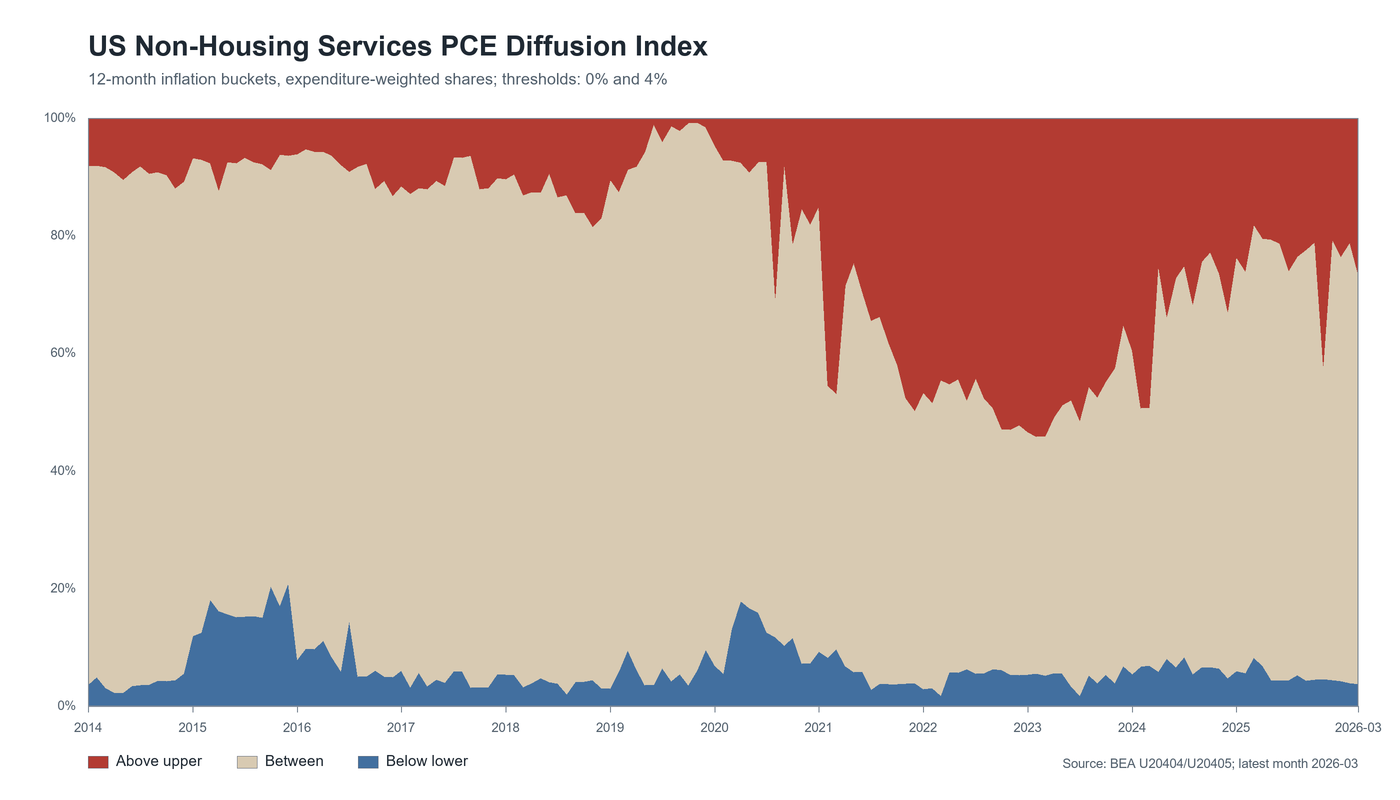

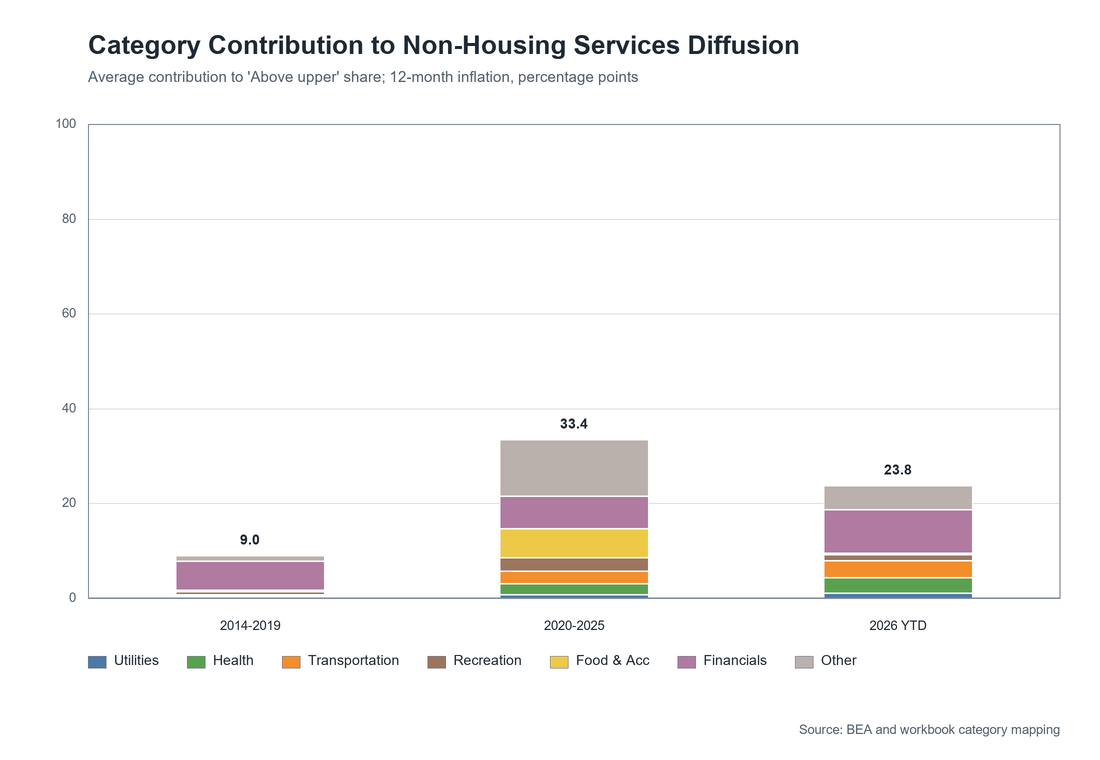

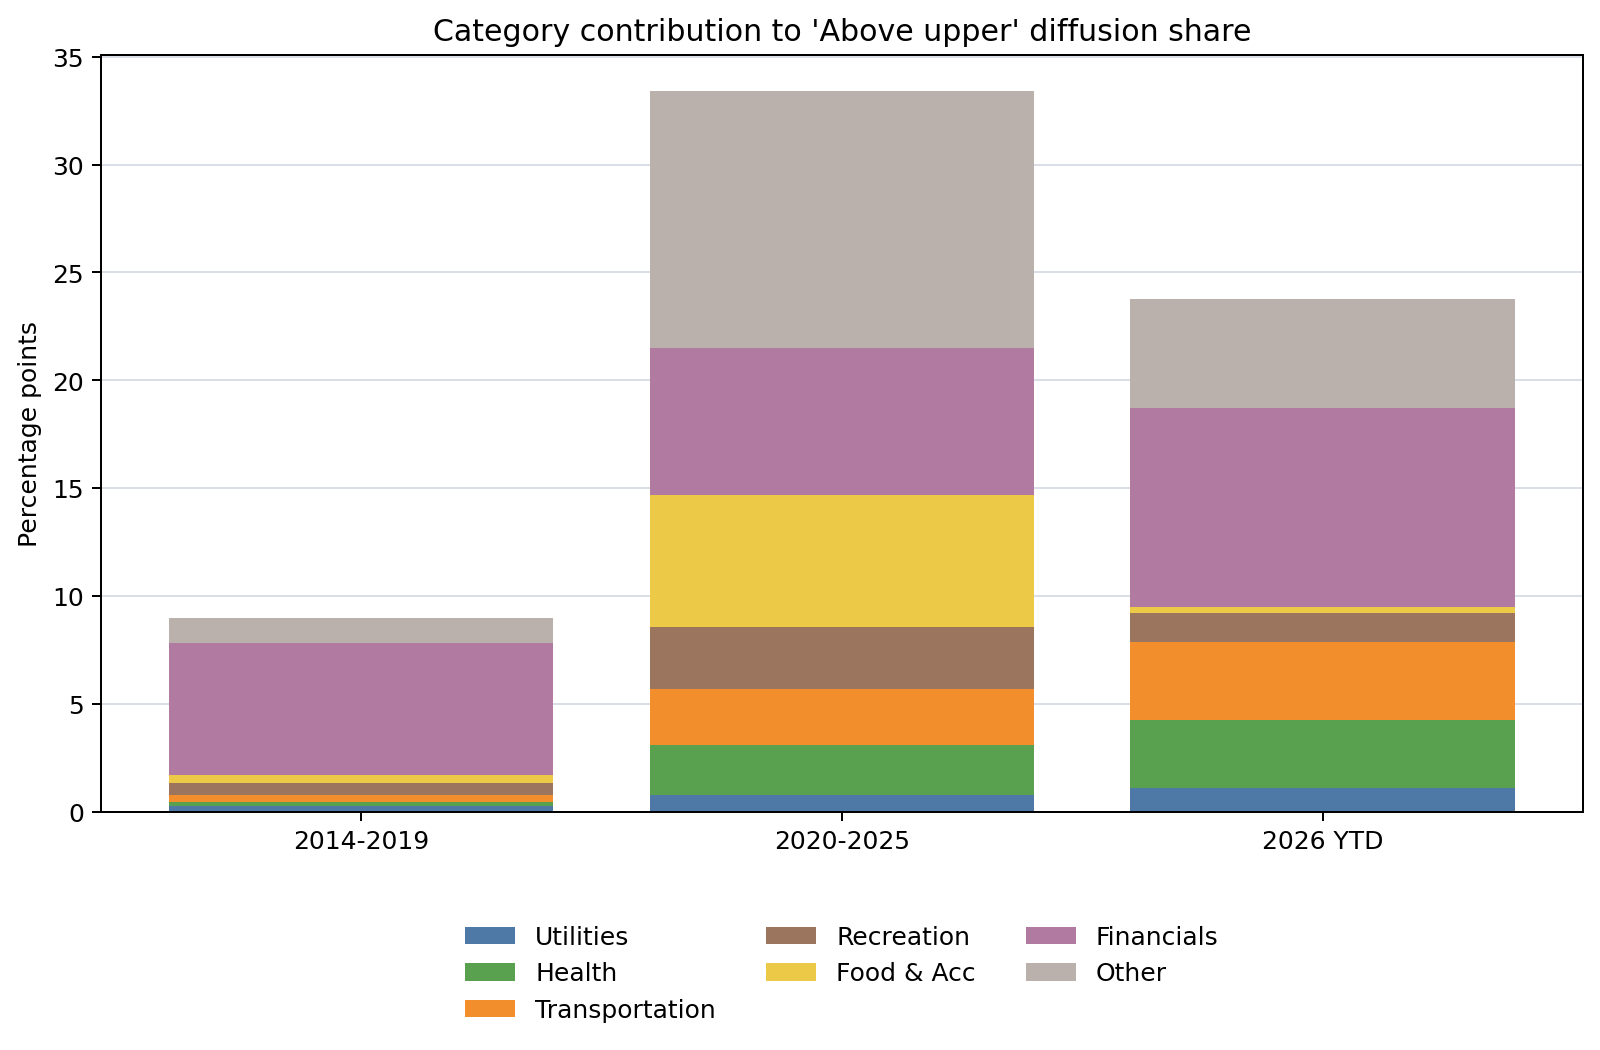

In [45]:
# Optional display when running in a notebook front end.
try:
    from IPython.display import Image as NotebookImage, display

    display(NotebookImage(filename=str(chart_path)))
    display(NotebookImage(filename=str(category_chart_path)))
    if matplotlib_category_chart_path.exists():
        display(NotebookImage(filename=str(matplotlib_category_chart_path)))
except Exception:
    pass
